In [2]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["Normal", "Anomalous"]

In [5]:
# Generate synthetic complaint dataset
np.random.seed(RANDOM_SEED)

n_normal = 4900
n_anomalous = 100

# Normal complaints
normal_data = pd.DataFrame({
    'ComplaintLength': np.random.normal(100, 30, n_normal),
    'ResponseTime': np.random.normal(30, 10, n_normal),
    'SentimentScore': np.random.uniform(-0.5, 1.0, n_normal),
    'PriorityScore': np.random.choice([1, 2, 3, 4, 5], n_normal),
    'ResolutionTime': np.random.normal(48, 15, n_normal),
    'DuplicateFlag': np.zeros(n_normal, dtype=int),
    'Class': np.zeros(n_normal, dtype=int)
})

# Anomalous complaints
anomalous_data = pd.DataFrame({
    'ComplaintLength': np.random.normal(150, 40, n_anomalous),
    'ResponseTime': np.random.normal(15, 5, n_anomalous),
    'SentimentScore': np.random.uniform(-1.0, -0.3, n_anomalous),
    'PriorityScore': np.random.choice([4, 5], n_anomalous),
    'ResolutionTime': np.random.uniform(0.5, 11.3, n_anomalous),
    'DuplicateFlag': np.ones(n_anomalous, dtype=int),
    'Class': np.ones(n_anomalous, dtype=int)
})

# Combine the data
data = pd.concat([normal_data, anomalous_data], ignore_index=True)
data.head()

,ComplaintLength,ResponseTime,SentimentScore,PriorityScore,ResolutionTime,DuplicateFlag,Class
0,114.901425,26.081232,0.518556,1,23.675979,0,0
1,95.852071,19.822357,0.748339,1,51.657655,0,0
2,119.430656,19.725964,0.188152,3,44.243560,0,0
3,145.690896,26.267318,0.390410,2,37.071747,0,0
4,92.975399,36.445185,-0.098983,2,49.312895,0,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ComplaintLength  5000 non-null   float64
 1   ResponseTime     5000 non-null   float64
 2   SentimentScore   5000 non-null   float64
 3   PriorityScore    5000 non-null   int64  
 4   ResolutionTime   5000 non-null   float64
 5   DuplicateFlag    5000 non-null   int64  
 6   Class            5000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 273.6 KB


In [7]:
data.isnull().values.any()

np.False_

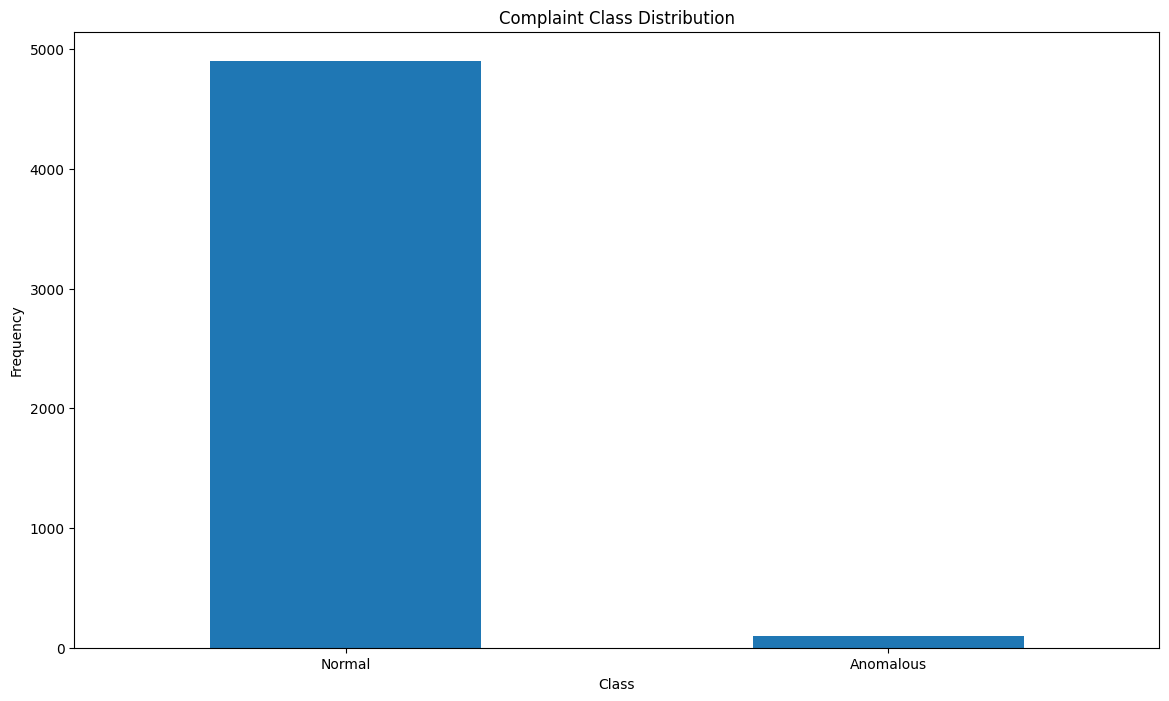

In [8]:
count_classes = data['Class'].value_counts(sort=True)
count_classes.plot(kind='bar', rot=0)
plt.title("Complaint Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

In [9]:
anomalous = data[data['Class']==1]
normal = data[data['Class']==0]
print(anomalous.shape, normal.shape)

(100, 7) (4900, 7)


In [10]:
anomalous.ResolutionTime.describe()

,ResolutionTime
count,100.000000
mean,6.097393
std,3.047276
min,0.781153
25%,3.586051
50%,6.077823
75%,8.626914
max,11.296713


In [14]:
normal.ResolutionTime.describe()

,ResolutionTime
count,4900.000000
mean,48.378576
std,15.012479
min,-5.114417
25%,38.194262
50%,48.210217
75%,58.573605
max,105.100760


<function matplotlib.pyplot.show(close=None, block=None)>

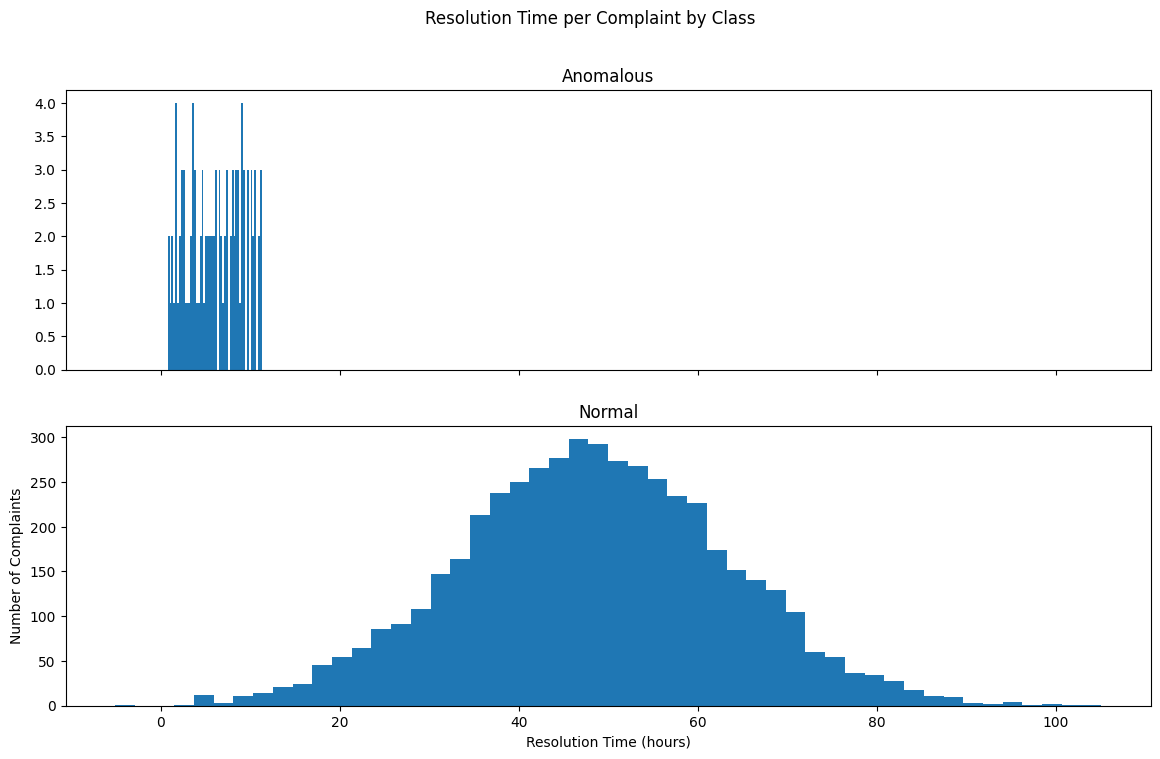

In [16]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Resolution Time per Complaint by Class')
bins = 50
ax1.hist(anomalous.ResolutionTime, bins=bins)
ax1.set_title('Anomalous')
ax2.hist(normal.ResolutionTime, bins=bins)
ax2.set_title('Normal')
plt.xlabel('Resolution Time (hours)')
plt.ylabel('Number of Complaints')
plt.show

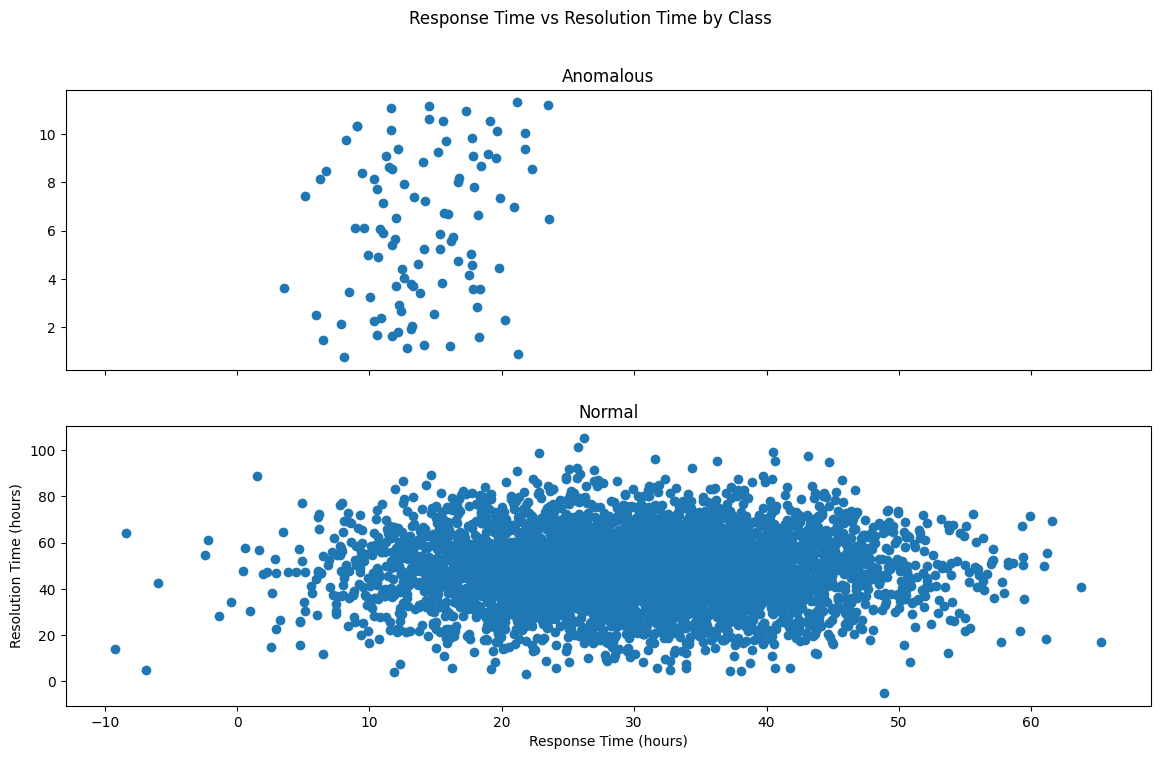

In [17]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Response Time vs Resolution Time by Class')
ax1.scatter(anomalous.ResponseTime, anomalous.ResolutionTime)
ax1.set_title('Anomalous')
ax2.scatter(normal.ResponseTime, normal.ResolutionTime)
ax2.set_title('Normal')
plt.xlabel('Response Time (hours)')
plt.ylabel('Resolution Time (hours)')
plt.show()

In [18]:
data = data.sample(frac=0.5, random_state=1)
data.shape

(2500, 7)

In [19]:
Anomalous = data[data['Class']==1]
Valid = data[data['Class']==0]
outlier_fraction = len(Anomalous)/float(len(Valid))
print(outlier_fraction)
print("Anomalous Cases : {}".format(len(Anomalous)))
print("Valid Cases : {}".format(len(Valid)))

0.017915309446254073
Anomalous Cases : 44
Valid Cases : 2456


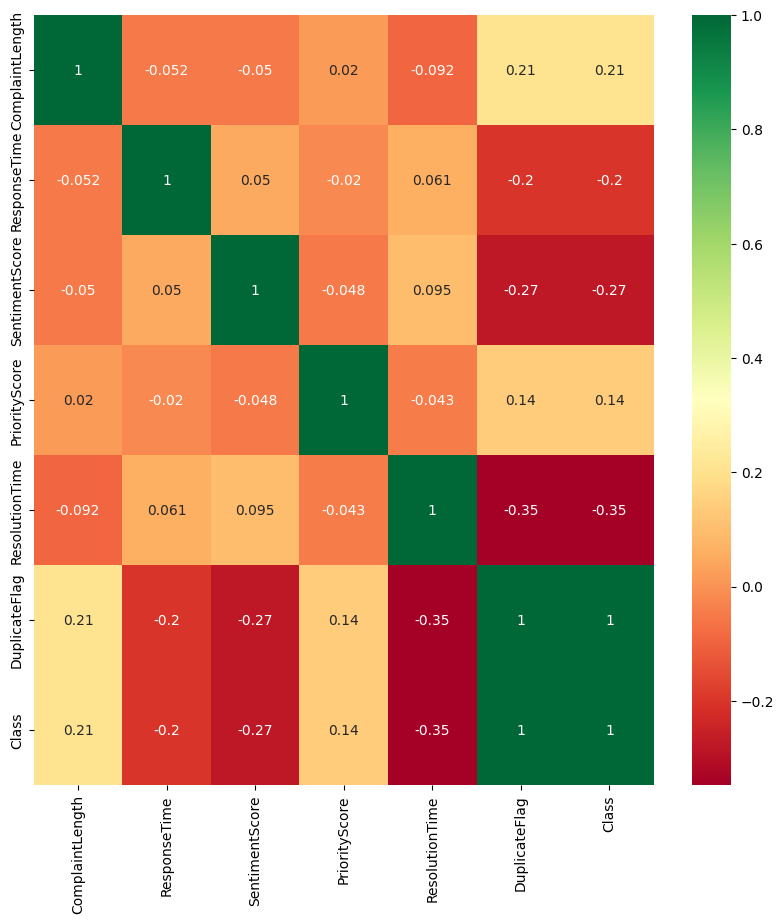

In [20]:
# Perform Isolation Forest Algorithm and Local Outlier Factor (LOF) Algorithm
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(10,10))
g = sns.heatmap(data[top_corr_features].corr(), annot=True, cmap="RdYlGn")

In [21]:
columns = data.columns.tolist()
columns = [c for c in columns if c not in ["Class"]]
target = "Class"
state = np.random.RandomState(42)
X = data[columns]
Y = data[target]
print(X.shape)
print(Y.shape)

(2500, 6)
(2500,)


In [23]:
classifiers = {     "Isolation Forest": IsolationForest(
    n_estimators=100,
    max_samples=len(X),
    contamination=outlier_fraction,
    random_state=state,
    verbose=0
    ),
    "Local Outlier Factor": LocalOutlierFactor(
                n_neighbors=20,
                algorithm='auto',
                leaf_size=30,
                metric='minkowski',
                p=2,
                metric_params=None,
                contamination=outlier_fraction
                )
    }
n_outliers = len(Anomalous)
for i, (clf_name, clf) in enumerate(classifiers.items()):
    if clf_name == "Local Outlier Factor":
         y_pred = clf.fit_predict(X)
         scores_prediction = clf.negative_outlier_factor_
    else:
       clf.fit(X)
       scores_prediction = clf.decision_function(X)
       y_pred = clf.predict(X)
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1
    n_errors = (y_pred != Y).sum()
    print("{}: {}".format(clf_name, n_errors))
    print("Accuracy Score :")
    print(accuracy_score(Y, y_pred))
    print("Classification Report :")
    print(classification_report(Y, y_pred))

Isolation Forest: 17
Accuracy Score :
0.9932
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2456
           1       0.80      0.82      0.81        44

    accuracy                           0.99      2500
   macro avg       0.90      0.91      0.90      2500
weighted avg       0.99      0.99      0.99      2500

Local Outlier Factor: 83
Accuracy Score :
0.9668
Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2456
           1       0.07      0.07      0.07        44

    accuracy                           0.97      2500
   macro avg       0.52      0.53      0.53      2500
weighted avg       0.97      0.97      0.97      2500

